In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import csv

# Load the dataset
data = pd.read_csv(r'C:\Users\masjk\Downloads\Delayed_Cancelled_Flights.csv')
data.head(20)

,FL_DATE,MONTH,DAY_OF_WEEK,OP_CARRIER_FL_NUM,ORIGIN,DEST,DEP_DELAY,ARR_DELAY,CANCELLED,CANCELLATION_CODE,WEATHER_DELAY,NAS_DELAY,CARRIER_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DELAYED
0,2/1/2024 12:00:00 AM,2,4,4865.0,MEM,LGA,-5.0,28.0,0.0,NaN,0.0,28.0,0.0,0.0,0.0,True
1,2/1/2024 12:00:00 AM,2,4,4906.0,LGA,PIT,121.0,112.0,0.0,NaN,0.0,0.0,112.0,0.0,0.0,True
2,2/1/2024 12:00:00 AM,2,4,4912.0,DHN,ATL,167.0,154.0,0.0,NaN,0.0,0.0,0.0,0.0,154.0,True
3,2/1/2024 12:00:00 AM,2,4,4916.0,LGA,DSM,30.0,18.0,0.0,NaN,0.0,0.0,18.0,0.0,0.0,True
4,2/1/2024 12:00:00 AM,2,4,4944.0,ATL,DHN,0.0,29.0,0.0,NaN,0.0,29.0,0.0,0.0,0.0,True
5,2/1/2024 12:00:00 AM,2,4,4961.0,JFK,MSP,9.0,23.0,0.0,NaN,0.0,14.0,9.0,0.0,0.0,True
6,2/1/2024 12:00:00 AM,2,4,4965.0,LGA,PNS,73.0,35.0,0.0,NaN,0.0,0.0,34.0,0.0,1.0,True
7,2/1/2024 12:00:00 AM,2,4,4972.0,CHO,LGA,12.0,16.0,0.0,NaN,0.0,4.0,5.0,0.0,7.0,True
8,2/1/2024 12:00:00 AM,2,4,5006.0,RDU,DCA,4.0,15.0,0.0,NaN,0.0,15.0,0.0,0.0,0.0,True
9,2/1/2024 12:00:00 AM,2,4,5041.0,BHM,LGA,93.0,107.0,0.0,NaN,0.0,14.0,93.0,0.0,0.0,True


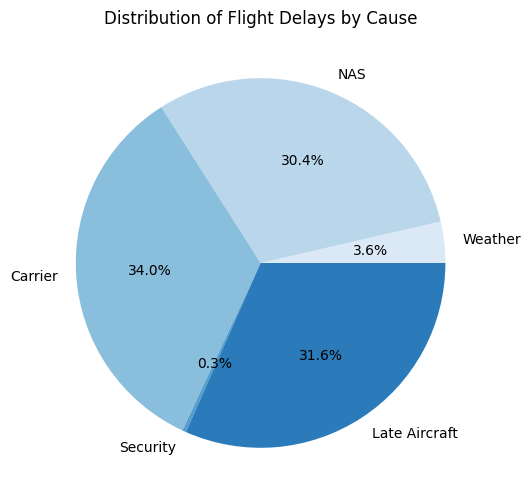

In [ ]:
#DIVIDING INTO DELAY TYPES 

weather = data[data['WEATHER_DELAY'] > 0]
nas = data[data['NAS_DELAY'] > 0]
carrier = data[data['CARRIER_DELAY'] > 0]
security = data[data['SECURITY_DELAY'] > 0]
late_aircraft = data[data['LATE_AIRCRAFT_DELAY'] > 0]

plt.figure(figsize=(10, 6))
plt.pie([len(weather), len(nas), len(carrier), len(security), len(late_aircraft)],
        labels=['Weather', 'NAS', 'Carrier', 'Security', 'Late Aircraft'], colors=sns.color_palette('Blues'), autopct='%1.1f%%')
plt.title('Distribution of Flight Delays by Cause')
plt.show()

               Delay Pair   Count
8   Carrier&Late Aircraft  370353
4             NAS&Carrier  300504
6       NAS&Late Aircraft  276182
0             Weather&NAS   44261
3   Weather&Late Aircraft   33659
5            NAS&Security    3650
9  Security&Late Aircraft    3592
1         Weather&Carrier    2963
7        Carrier&Security     688
2        Weather&Security      24


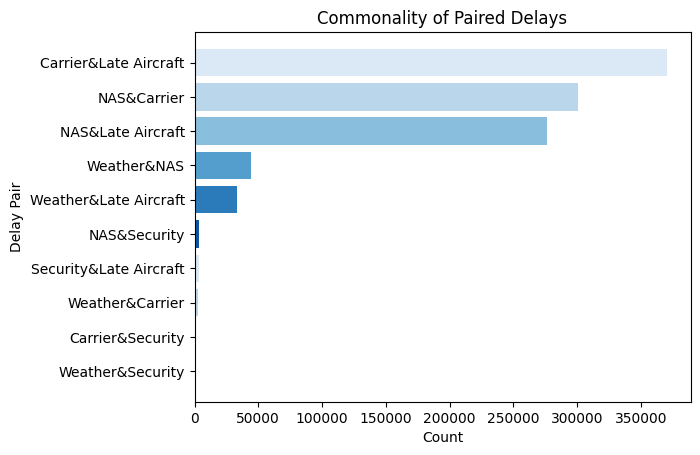

In [ ]:
#PAIRED DELAYS

paired_delays = {"Weather&NAS": 0, "Weather&Carrier": 0, "Weather&Security": 0, "Weather&Late Aircraft": 0,
                 "NAS&Carrier": 0, "NAS&Security": 0, "NAS&Late Aircraft": 0, "Carrier&Security": 0, "Carrier&Late Aircraft": 0, "Security&Late Aircraft": 0}



with open(r'C:\Users\masjk\Downloads\Delayed_Cancelled_Flights.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        weather = float(row['WEATHER_DELAY'] or 0)
        nas = float(row['NAS_DELAY'] or 0)
        carrier = float(row['CARRIER_DELAY'] or 0)
        security = float(row['SECURITY_DELAY'] or 0)
        late = float(row['LATE_AIRCRAFT_DELAY'] or 0)
        if weather > 0 and nas > 0:
            paired_delays["Weather&NAS"] += 1
        if weather > 0 and carrier > 0:
            paired_delays["Weather&Carrier"] += 1
        if weather > 0 and security > 0:
            paired_delays["Weather&Security"] += 1
        if weather > 0 and late > 0:
            paired_delays["Weather&Late Aircraft"] += 1
        if nas > 0 and carrier > 0:
            paired_delays["NAS&Carrier"] += 1
        if nas > 0 and security > 0:
            paired_delays["NAS&Security"] += 1
        if nas > 0 and late > 0:
            paired_delays["NAS&Late Aircraft"] += 1
        if carrier > 0 and security > 0:
            paired_delays["Carrier&Security"] += 1
        if carrier > 0 and late > 0:
            paired_delays["Carrier&Late Aircraft"] += 1
        if security > 0 and late > 0:
            paired_delays["Security&Late Aircraft"] += 1
        

paired_delays_df = pd.DataFrame(list(paired_delays.items()), columns=['Delay Pair', 'Count'])
paired_delays_df_sorted = paired_delays_df.sort_values(by='Count', ascending=False)
print(paired_delays_df_sorted)

plt.barh(paired_delays_df_sorted['Delay Pair'], paired_delays_df_sorted['Count'], color=sns.color_palette('Blues'))
plt.xlabel('Count')
plt.ylabel('Delay Pair')
plt.title("Commonality of Paired Delays")
plt.gca().invert_yaxis()
plt.show()

In [34]:
#top 10 airports 
DFW = data[data['ORIGIN'] == 'DFW']
ATL = data[data['ORIGIN'] == 'ATL']
DEN = data[data['ORIGIN'] == 'DEN']
ORD = data[data['ORIGIN'] == 'ORD']
CLT = data[data['ORIGIN'] == 'CLT']
LAS = data[data['ORIGIN'] == 'LAS']
LAX = data[data['ORIGIN'] == 'LAX']
SEA = data[data['ORIGIN'] == 'SEA']
MCO = data[data['ORIGIN'] == 'MCO']
EWR = data[data['ORIGIN'] == 'EWR']

top10_airports = [DFW, ATL, DEN, ORD, CLT, LAS, LAX, SEA, MCO, EWR]

In [51]:
#finding each airport's total delay by type
DFW_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
ATL_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
DEN_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
ORD_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
CLT_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
LAS_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
LAX_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
SEA_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
MCO_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}
EWR_delays = {"weather": 0, "nas": 0, "carrier": 0, "security": 0, "late_aircraft": 0}

delay_cols = [
    'WEATHER_DELAY',
    'NAS_DELAY',
    'CARRIER_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]

# Make sure all delay columns are numeric
DFW[delay_cols] = DFW[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
ATL[delay_cols] = ATL[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
DEN[delay_cols] = DEN[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
ORD[delay_cols] = ORD[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
CLT[delay_cols] = CLT[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
LAS[delay_cols] = LAS[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
LAX[delay_cols] = LAX[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
SEA[delay_cols] = SEA[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
MCO[delay_cols] = MCO[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
EWR[delay_cols] = EWR[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Total delays per type for each airport
DFW_delays = DFW[delay_cols].sum().to_dict()
ATL_delays = ATL[delay_cols].sum().to_dict()
DEN_delays = DEN[delay_cols].sum().to_dict()
ORD_delays = ORD[delay_cols].sum().to_dict()
CLT_delays = CLT[delay_cols].sum().to_dict()
LAS_delays = LAS[delay_cols].sum().to_dict()
LAX_delays = LAX[delay_cols].sum().to_dict()
SEA_delays = SEA[delay_cols].sum().to_dict()
MCO_delays = MCO[delay_cols].sum().to_dict()
EWR_delays = EWR[delay_cols].sum().to_dict()

#SIMPLER WAY
top10_codes = ['DFW','ATL','DEN','ORD','CLT','LAS','LAX','SEA','MCO','EWR']

totals = (
    data[data['ORIGIN'].isin(top10_codes)]
    .groupby('ORIGIN')[delay_cols]
    .sum()
)

averages = (
    data[data['ORIGIN'].isin(top10_codes)]
    .groupby('ORIGIN')[delay_cols]
    .mean()
)

print(totals)
print(averages)

C:\Users\masjk\AppData\Local\Temp\ipykernel_4584\3367664572.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DFW[delay_cols] = DFW[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
C:\Users\masjk\AppData\Local\Temp\ipykernel_4584\3367664572.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ATL[delay_cols] = ATL[delay_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
C:\Users\masjk\AppData\Local\Temp\ipykernel_4584\3367664572.py:24: SettingWithCopyWarning: 
A value is trying to be set on

        WEATHER_DELAY  NAS_DELAY  CARRIER_DELAY  SECURITY_DELAY  \
ORIGIN                                                            
ATL          175618.0   777927.0      1946573.0          4086.0   
CLT          313849.0   528902.0      1214407.0         16633.0   
DEN          193240.0   785548.0      1505310.0          5790.0   
DFW          431782.0   757735.0      1891060.0          5925.0   
EWR          117579.0   513683.0       646115.0          2160.0   
LAS           70559.0   503390.0       883407.0          3368.0   
LAX           78787.0   502499.0       897125.0          3873.0   
MCO          184973.0   568963.0       815353.0         13802.0   
ORD          323696.0   904417.0      1457235.0          4445.0   
SEA           96107.0   392070.0       778152.0          4722.0   

        LATE_AIRCRAFT_DELAY  
ORIGIN                       
ATL               1125616.0  
CLT               1902979.0  
DEN               1840039.0  
DFW               2841721.0  
EWR            

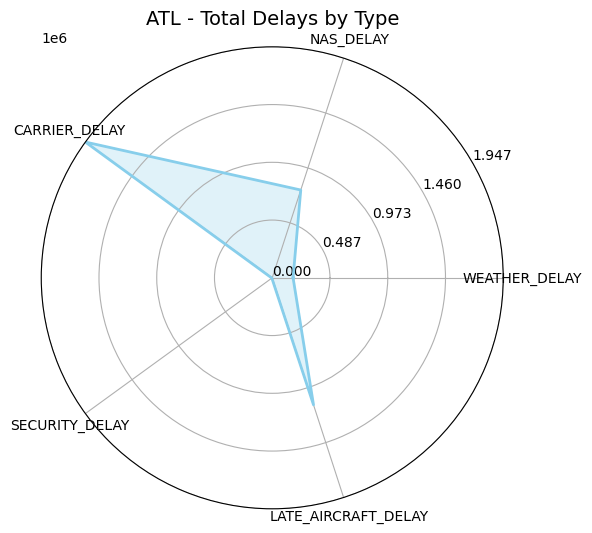

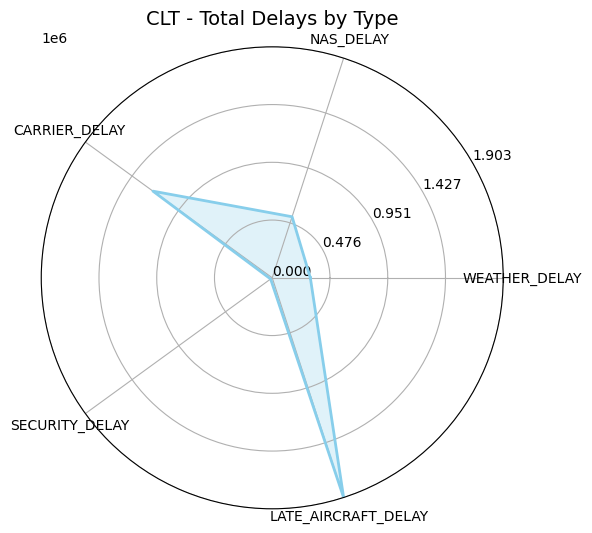

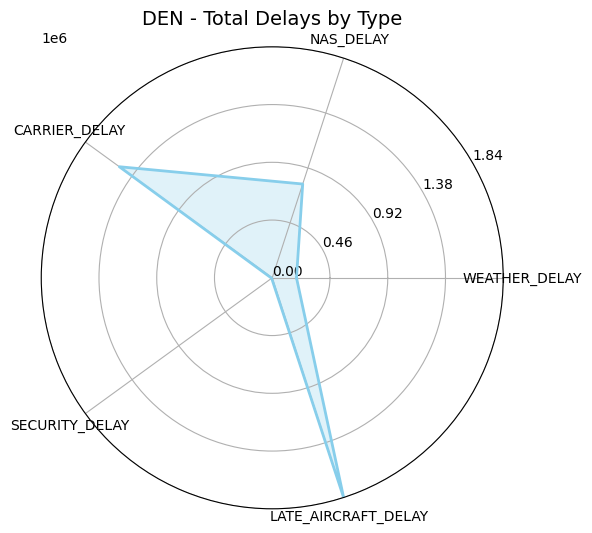

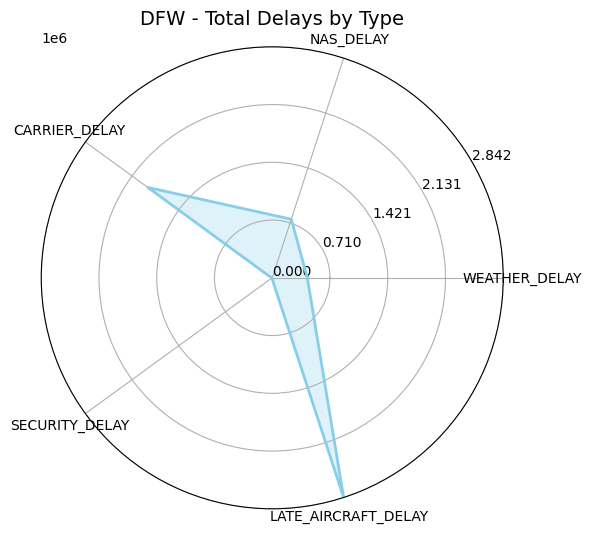

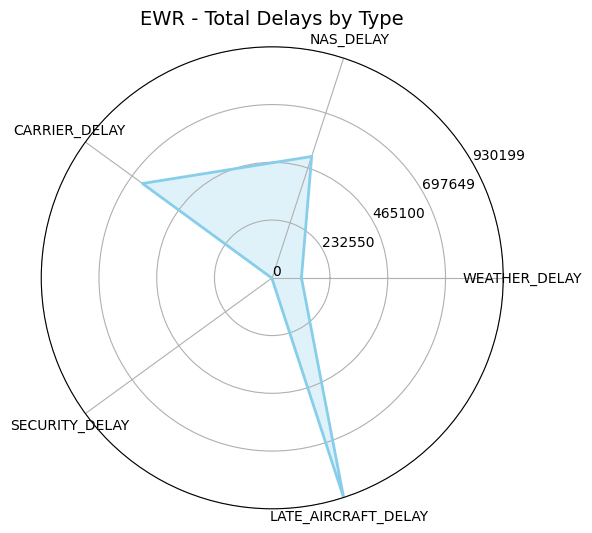

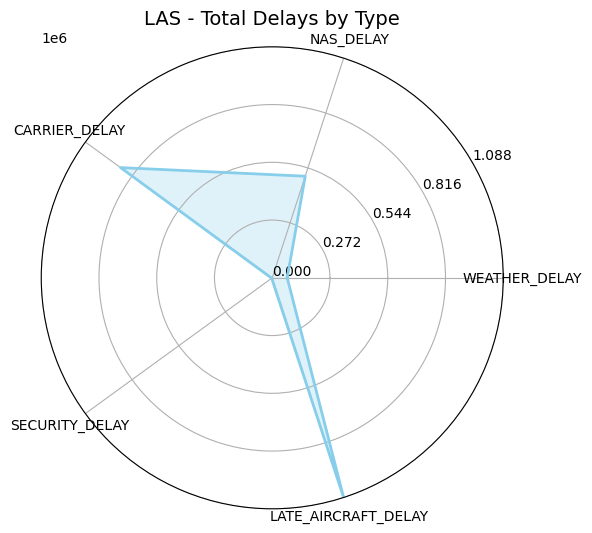

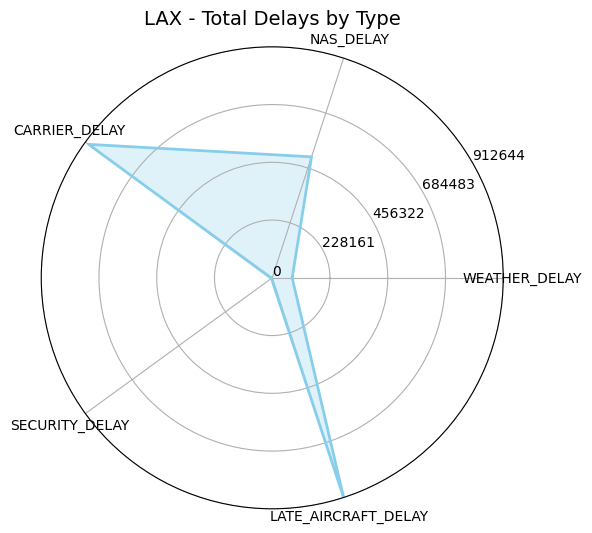

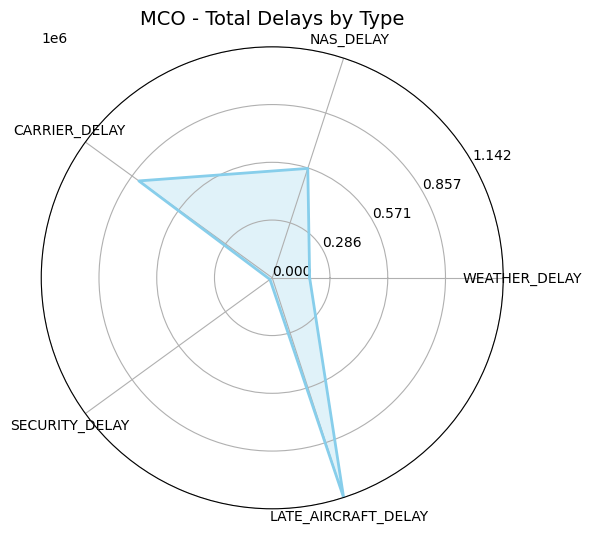

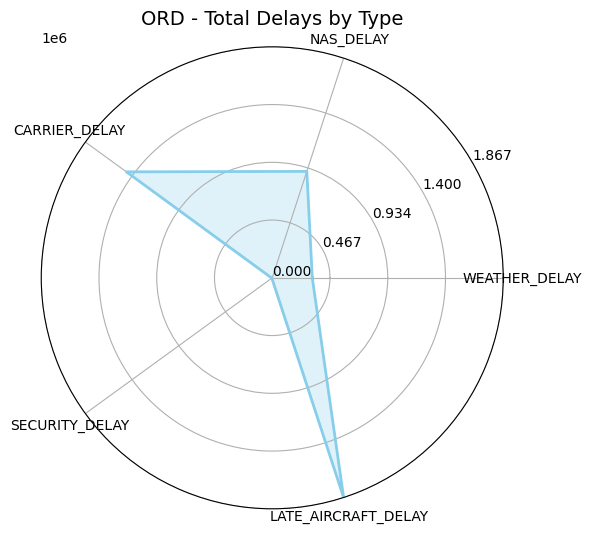

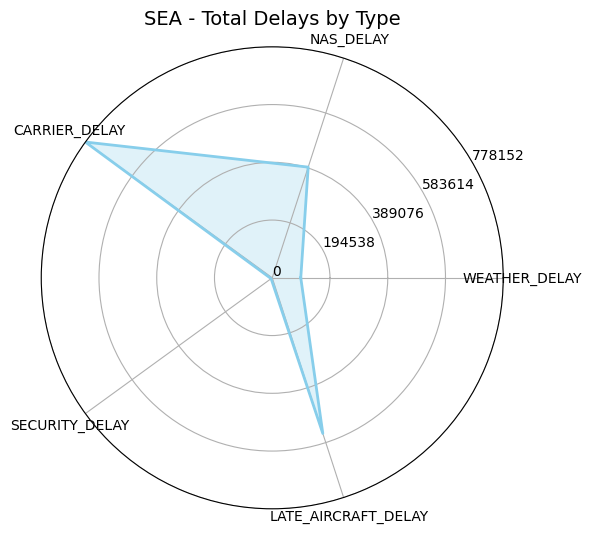

In [55]:
def plot_radar(data, airport_name, color='skyblue'):
    categories = list(data.index)
    values = data.values.flatten().tolist()
    
    # Close the circle
    values += values[:1]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]
    
    # Create plot
    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    
    ax.plot(angles, values, color=color, linewidth=2, label=airport_name)
    ax.fill(angles, values, color=color, alpha=0.25)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    
    # Optional: make y-axis start at 0
    ax.set_rlabel_position(30)
    ax.set_yticks(np.linspace(0, max(values), 5))
    ax.set_ylim(0, max(values))
    
    plt.title(f"{airport_name} - Total Delays by Type", size=14)
    plt.show()

for airport in totals.index:
    plot_radar(totals.loc[[airport]].T, airport)

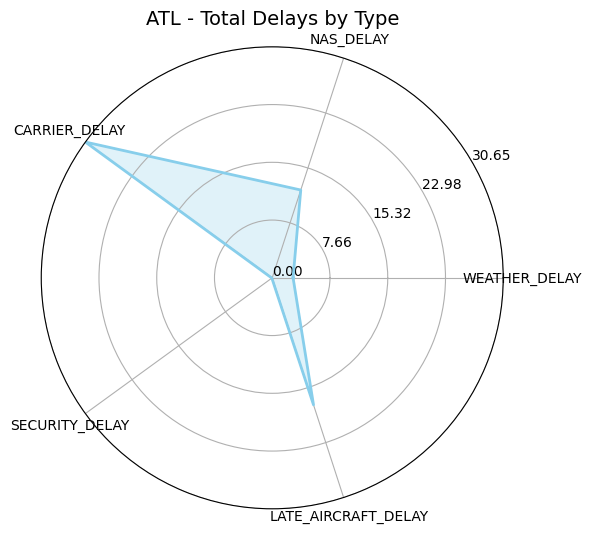

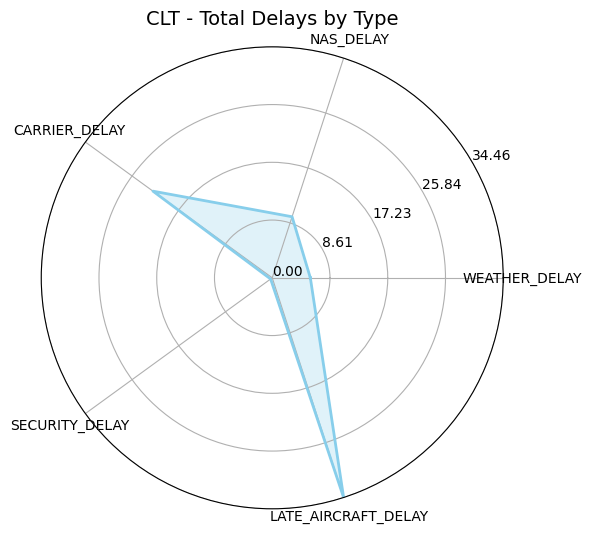

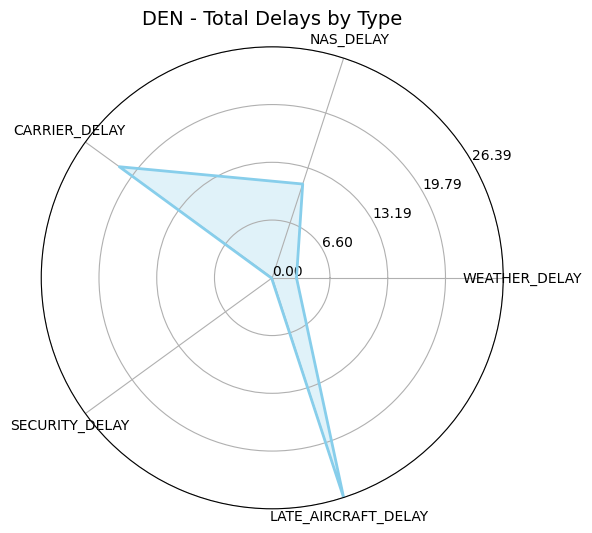

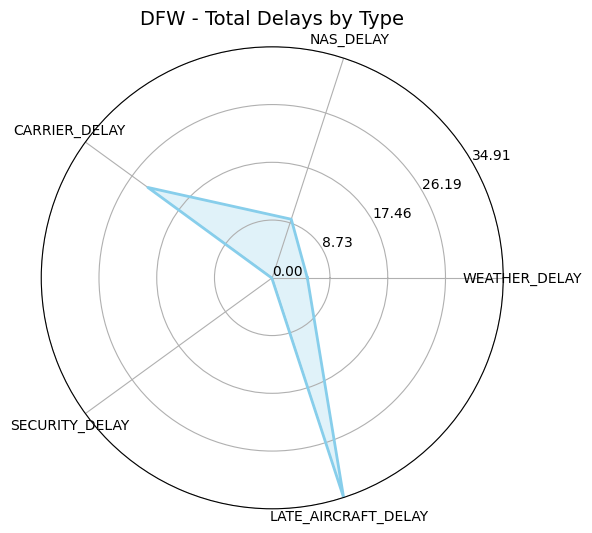

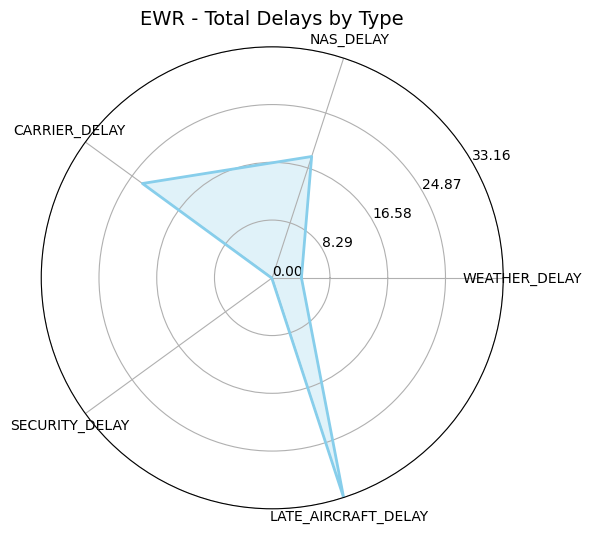

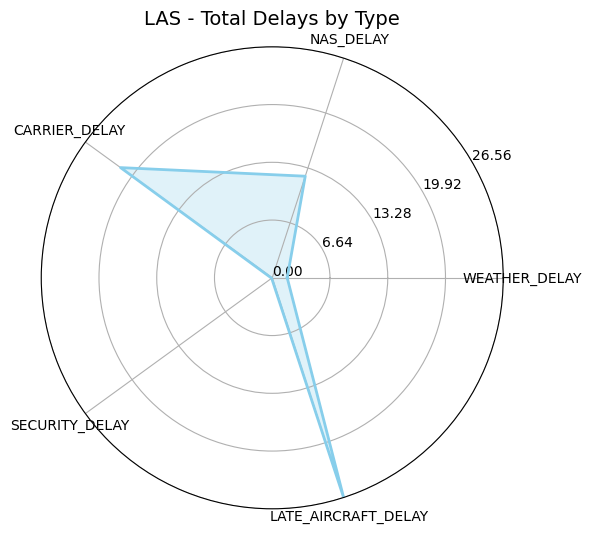

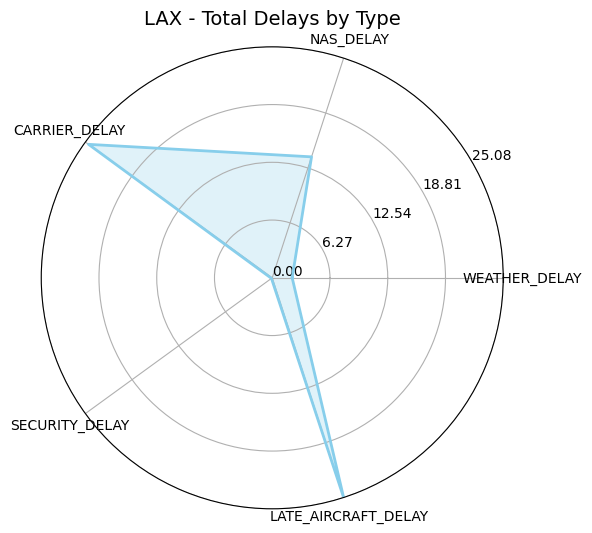

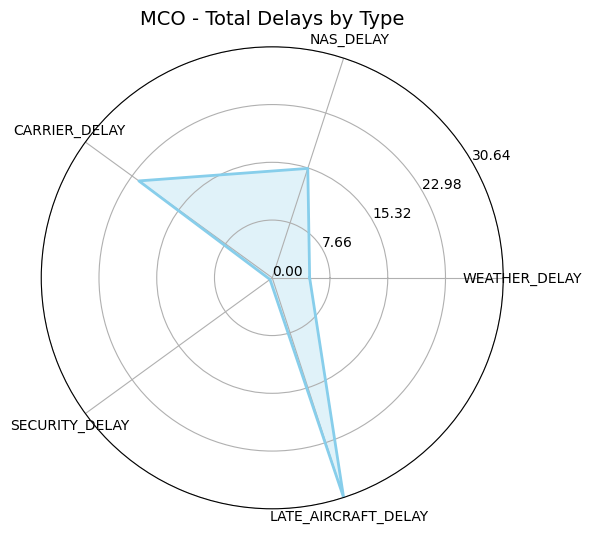

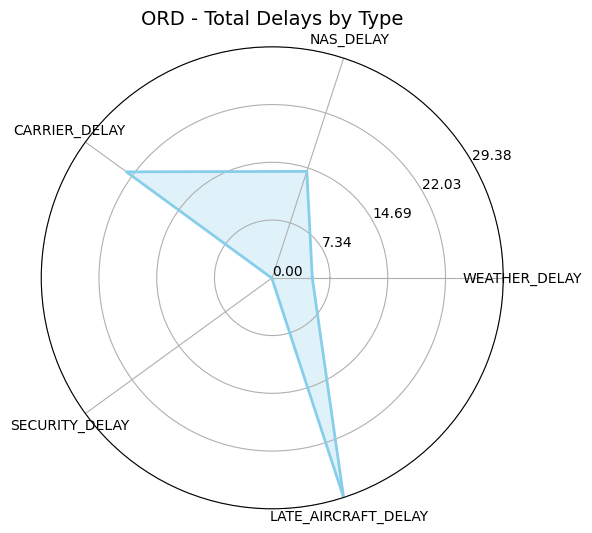

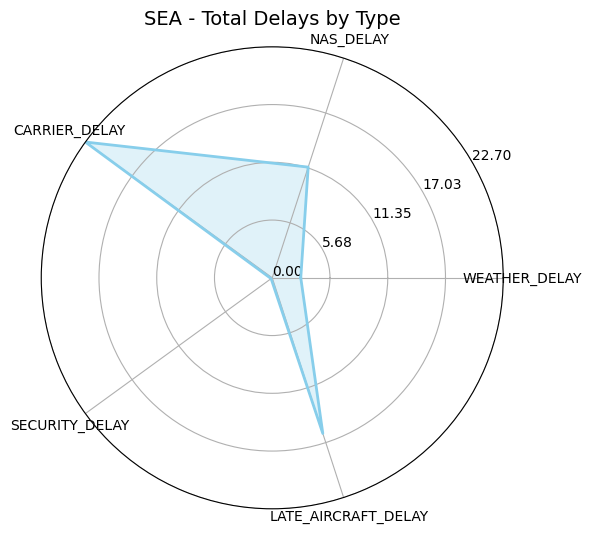

In [56]:
for airport in averages.index:
    plot_radar(averages.loc[[airport]].T, airport)

In [ ]:
#STILL TO ADD: Radar/Spider plot for each of top 10 airports by total/avg delay length by type, Most commonly delayed routes, Stacked bar chart of delay types by airport, heatmap?
